# Results Dashboard

Visualizes experiment results from the centralized `results/experiment_results.csv`.

This CSV is automatically populated by `graphium-train` after each run.
Each row = one training run with metadata and all test metrics.

# 0. Loading

Imports, data loading, and preprocessing.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from notebook_utils import (
    ADMET_TASK_ORDER, TASK_CATEGORY, TASK_METRICS, TDC_SOTA, MINIMOL_GIT, MOLE, MOLGPS,
    MODEL_REGISTRY, FAMILY_COLORS, FAMILY_HATCHES,
    infer_model_name, infer_model_family, build_method_label, parse_pretrain_dataset,
    load_results, load_tdc_top10, build_method_colors,
    normalize_scores, count_best_among_methods, find_metric_column, get_sota,
)

# === Config: select which model(s) to show ===
MODELS_TO_SHOW = [
    'gpspp_800M',
    'pairmixer_12M',
    'pairmixer_20M',
]

df, admet_df = load_results(models_to_show=MODELS_TO_SHOW)
print(f"Loaded {len(df)} rows, {len(admet_df)} ADMET rows")
print(f"Models: {admet_df['model_name'].value_counts().to_dict()}")

# TDC top-10 data
TDC_TOP10_ALL, TDC_TOP10_AVG, TDC_TOP10_MEDIAN = load_tdc_top10()

# Method colors (dynamic from data)
METHOD_COLORS = build_method_colors(admet_df)
# Swap colors between toymix_dti_esmc_v2 and dti so ESMC is blue.
if 'toymix_dti_esmc_v2' in METHOD_COLORS and 'dti' in METHOD_COLORS:
    METHOD_COLORS['toymix_dti_esmc_v2'], METHOD_COLORS['dti'] = (
        METHOD_COLORS['dti'], METHOD_COLORS['toymix_dti_esmc_v2'],
    )

# Default variant per family (used in the main per-task chart)
DEFAULT_VARIANT = {
    'GPS++':      'gpspp_800M',
    'PairMixer':  'pairmixer_12M',
}

print(f"Methods: {sorted(admet_df['method'].unique())}")


/home/shpark/prj-molrepr/graphium/notebooks/notebook_utils.py:384: DtypeWarning: Columns (15,17,18,19,21,22,24,311) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


Loaded 1226 rows, 528 ADMET rows
Models: {'gpspp_800M': 330, 'pairmixer_20M': 132, 'pairmixer_12M': 66}
Methods: ['Scratch', 'dti', 'dti_pactivity', 'largemix', 'largemix_dti', 'rxrx3', 'rxrx3_dti', 'toymix', 'toymix_bbbc047', 'toymix_dti', 'toymix_dti_esmc_v2', 'toymix_dti_filtered', 'toymix_dti_pactivity', 'toymix_dti_v2', 'toymix_lpm24', 'toymix_rxrx3', 'toymix_rxrx3_dti']


### Runs overview

In [2]:
print("Runs by model:")
print(df['model_name'].value_counts().to_string())
print()
print("Runs by task:")
print(df['task'].value_counts().to_string())
print()
df['is_finetuning'] = df['is_finetuning'].fillna(False).astype(bool)
print(f"Finetuned: {df['is_finetuning'].sum()} / Scratch: {(~df['is_finetuning']).sum()}")

Runs by model:
model_name
gpspp_800M       782
pairmixer_20M    227
pairmixer_12M    217

Runs by task:
task
caco2_wang                        210
multitask                          91
solubility_aqsoldb                 71
ld50_zhu                           68
clearance_microsome_az             67
half_life_obach                    56
bbb_martins                        56
clearance_hepatocyte_az            54
cyp2d6_veith                       47
pgp_broccatelli                    41
hia_hou                            40
lipophilicity_astrazeneca          37
vdss_lombardo                      36
ppbr_az                            36
bioavailability_ma                 35
herg                               33
cyp3a4_veith                       32
dili                               32
cyp2c9_veith                       31
cyp3a4_substrate_carbonmangels     31
cyp2d6_substrate_carbonmangels     31
cyp2c9_substrate_carbonmangels     31
ames                               31
adme_fang_hclint 

### Metric extraction

In [3]:
# Primary metrics already extracted by load_results() above.
# Report extraction stats.
print(f"Tasks with extracted metrics: {df['primary_metric'].notna().sum()} / {len(df)}")

_failed = df[df['primary_metric'].isna()]
if len(_failed) > 0:
    print(f"\nFailed metric extraction ({len(_failed)} rows):")
    for task, count in _failed['task'].value_counts().items():
        if task not in TASK_METRICS:
            reason = "task not in TASK_METRICS (not an ADMET single-task)"
        else:
            metric_name, _ = TASK_METRICS[task]
            col = find_metric_column(df, task, metric_name)
            reason = f"metric column not found for '{metric_name}'" if col is None else "metric value is NaN"
        print(f"  - task='{task}' x {count} rows  ({reason})")

Tasks with extracted metrics: 1059 / 1226

Failed metric extraction (167 rows):
  - task='multitask' x 91 rows  (task not in TASK_METRICS (not an ADMET single-task))
  - task='caco2_wang' x 7 rows  (metric value is NaN)
  - task='adme_fang_solu' x 4 rows  (task not in TASK_METRICS (not an ADMET single-task))
  - task='adme_fang_rppb' x 4 rows  (task not in TASK_METRICS (not an ADMET single-task))
  - task='DAVIS' x 4 rows  (task not in TASK_METRICS (not an ADMET single-task))
  - task='adme_fang_hppb' x 4 rows  (task not in TASK_METRICS (not an ADMET single-task))
  - task='adme_fang_perm' x 4 rows  (task not in TASK_METRICS (not an ADMET single-task))
  - task='adme_fang_hclint' x 4 rows  (task not in TASK_METRICS (not an ADMET single-task))
  - task='adme_fang_rclint' x 4 rows  (task not in TASK_METRICS (not an ADMET single-task))
  - task='hia_hou' x 3 rows  (metric value is NaN)
  - task='bbb_martins' x 3 rows  (metric value is NaN)
  - task='pgp_broccatelli' x 3 rows  (metric valu

# Task 1 - ADMET

## TDC ADMET

Compare downstream ADMET performance across pre-training datasets.

In [4]:
# Data pipeline (parse_pretrain_dataset, build_method_label, etc.) is handled
# by load_results() in cell 1. admet_df is ready to use.

print(f"ADMET results: {len(admet_df)} rows")
print(f"Methods: {sorted(admet_df['method'].unique())}")
print(f"Method colors: {METHOD_COLORS}")

# --- Compute global best (across all architectures) per task ---
global_best_per_task = {}  # task -> (model_name, method)
if len(admet_df) > 0 and admet_df['primary_metric'].notna().any():
    for task in ADMET_TASK_ORDER:
        task_rows = admet_df[admet_df['task'] == task].dropna(subset=['primary_metric'])
        if len(task_rows) == 0:
            continue
        direction = TASK_METRICS.get(task, (None, 'higher'))[1]
        if direction == 'lower':
            best_row = task_rows.loc[task_rows['primary_metric'].idxmin()]
        else:
            best_row = task_rows.loc[task_rows['primary_metric'].idxmax()]
        global_best_per_task[task] = (best_row['model_name'], best_row['method'])

# --- Display one table per architecture ---
if len(admet_df) > 0 and admet_df['primary_metric'].notna().any():
    for model_name in MODELS_TO_SHOW:
        model_df = admet_df[admet_df['model_name'] == model_name]

        if len(model_df) == 0 or model_df['primary_metric'].isna().all():
            # No data at all — show empty table with all tasks
            pivot = pd.DataFrame(index=ADMET_TASK_ORDER, columns=['(no results)'])
            pivot['(no results)'] = np.nan
        else:
            pivot = model_df.pivot_table(
                index='task', columns='method', values='primary_metric', aggfunc='mean'
            )
            method_order = ['Scratch'] + sorted([c for c in pivot.columns if c != 'Scratch'])
            method_order += [c for c in pivot.columns if c not in method_order]
            pivot = pivot[[c for c in method_order if c in pivot.columns]]

        # Reindex to always show all 22 ADMET tasks (NaN for missing)
        pivot = pivot.reindex(ADMET_TASK_ORDER)

        row_labels = []
        for task in pivot.index:
            metric_name, direction = TASK_METRICS.get(task, ('?', 'higher'))
            arrow = '\u2191' if direction == 'higher' else '\u2193'
            row_labels.append(f'{task}  ({metric_name} {arrow})')

        # Find best column per row within this architecture
        arch_best_per_row = {}
        for task in pivot.index:
            direction = TASK_METRICS.get(task, (None, 'higher'))[1]
            row_vals = pivot.loc[task].dropna()
            if len(row_vals) > 0:
                best_col = row_vals.idxmin() if direction == 'lower' else row_vals.idxmax()
                arch_best_per_row[task] = best_col

        numeric_pivot = pivot.copy()

        # Insert TDC SOTA column on the left
        sota_col = []
        for task in pivot.index:
            if task in TDC_SOTA:
                mean, std, _ = TDC_SOTA[task]
                sota_col.append(f'{mean:.3f} \u00b1 {std:.3f}')
            else:
                sota_col.append('')
        pivot.insert(0, 'TDC SOTA', sota_col)

        # Compute category boundaries
        category_boundaries = set()
        prev_cat = None
        for i, task in enumerate(pivot.index):
            cat = TASK_CATEGORY.get(task)
            if prev_cat is not None and cat != prev_cat:
                category_boundaries.add(i)
            prev_cat = cat

        display_pivot = pivot.copy()
        display_pivot.index = row_labels

        # Styling: bold = best within arch, blue+underline = best across all archs
        def make_highlight(arch_best, global_best, cur_model, dp, pv):
            def highlight(row):
                task = pv.index[dp.index.get_loc(row.name)]
                styles = [''] * len(row)
                cols = list(dp.columns)
                metric_info = TASK_METRICS.get(task, (None, None))
                direction = metric_info[1]
                sota_info = TDC_SOTA.get(task)

                for j, col in enumerate(cols):
                    if col == 'TDC SOTA':
                        continue
                    try:
                        val = float(row.iloc[j])
                    except (ValueError, TypeError):
                        continue
                    if pd.isna(val):
                        continue

                    # Check if value exceeds SOTA (within std)
                    exceeds_sota = False
                    if sota_info is not None and direction is not None:
                        sota_mean, sota_std, _ = sota_info
                        if direction == 'higher' and val >= sota_mean - sota_std:
                            exceeds_sota = True
                        elif direction == 'lower' and val <= sota_mean + sota_std:
                            exceeds_sota = True

                    if exceeds_sota:
                        styles[j] = 'font-weight: bold; color: #cc0000'

                # Architecture best: bold (overrides red if not exceeding SOTA)
                if task in arch_best:
                    j = cols.index(arch_best[task])
                    if 'color: #cc0000' not in styles[j]:
                        styles[j] = 'font-weight: bold'

                # Global best: blue + underline (overrides arch-best, but not red)
                if task in global_best:
                    g_model, g_method = global_best[task]
                    if g_model == cur_model and g_method in cols:
                        k = cols.index(g_method)
                        if 'color: #cc0000' not in styles[k]:
                            styles[k] = 'font-weight: bold; color: #1a5fb4; text-decoration: underline'

                return styles
            return highlight

        def make_category_borders(boundaries, dp):
            def category_borders(row):
                idx = dp.index.get_loc(row.name)
                if idx in boundaries:
                    return ['border-top: 3px solid black'] * len(row)
                return [''] * len(row)
            return category_borders

        def sota_style(col):
            if col.name == 'TDC SOTA':
                return ['background-color: #f0f0f0; color: #555; font-size: 0.9em'] * len(col)
            return [''] * len(col)

        styled = (
            display_pivot.style
            .format(precision=4, na_rep='',
                    subset=[c for c in display_pivot.columns if c != 'TDC SOTA'])
            .apply(make_highlight(arch_best_per_row, global_best_per_task,
                                  model_name, display_pivot, pivot), axis=1)
            .apply(make_category_borders(category_boundaries, display_pivot), axis=1)
            .apply(sota_style, axis=0)
            .set_caption(f'{model_name} — ADMET Performance (TDC SOTA on left for reference)')
            .set_table_styles([
                {'selector': 'th', 'props': [('font-weight', 'bold')]},
                {'selector': 'td', 'props': [('text-align', 'center')]},
            ])
        )

        print(f"\n{'='*60}")
        print(f"  {model_name}")
        print(f"{'='*60}")
        print("Bold = best within architecture | Blue + underline = best across all architectures")
        display(styled)

        # Count tasks where each method is the best
        best_counts = count_best_among_methods(numeric_pivot, list(numeric_pivot.columns), TASK_METRICS)
        if best_counts:
            print(f"\nTasks where each method is best ({model_name}):")
            for method, (wins, total) in best_counts.items():
                print(f"  {method}: {wins}/{total}")

    # --- Cross-architecture summary ---
    combined_pivot = admet_df.pivot_table(
        index='task', columns=['model_name', 'method'],
        values='primary_metric', aggfunc='mean'
    )
    combined_pivot = combined_pivot.loc[[t for t in ADMET_TASK_ORDER if t in combined_pivot.index]]
    all_cols = list(combined_pivot.columns)
    best_counts = count_best_among_methods(combined_pivot, all_cols, TASK_METRICS)

    print(f"\n{'='*60}")
    print("  Cross-architecture summary: tasks where each (model, method) is best")
    print(f"{'='*60}")
    for col, (wins, total) in best_counts.items():
        model, method = col
        print(f"  {model} / {method}: {wins}/{total}")
else:
    print("No ADMET results found yet. Run experiments first.")

ADMET results: 528 rows
Methods: ['Scratch', 'dti', 'dti_pactivity', 'largemix', 'largemix_dti', 'rxrx3', 'rxrx3_dti', 'toymix', 'toymix_bbbc047', 'toymix_dti', 'toymix_dti_esmc_v2', 'toymix_dti_filtered', 'toymix_dti_pactivity', 'toymix_dti_v2', 'toymix_lpm24', 'toymix_rxrx3', 'toymix_rxrx3_dti']
Method colors: {'Scratch': '#888888', 'dti': '#8c564b', 'dti_pactivity': '#64B478', 'largemix': '#EB423D', 'largemix_dti': '#FF883D', 'rxrx3': '#9B59B6', 'rxrx3_dti': '#17becf', 'toymix': '#bcbd22', 'toymix_bbbc047': '#e377c2', 'toymix_dti': '#d62728', 'toymix_dti_esmc_v2': '#466eff', 'toymix_dti_filtered': '#466eff', 'toymix_dti_pactivity': '#64B478', 'toymix_dti_v2': '#EB423D', 'toymix_lpm24': '#FF883D', 'toymix_rxrx3': '#9B59B6', 'toymix_rxrx3_dti': '#17becf'}

  gpspp_800M
Bold = best within architecture | Blue + underline = best across all architectures


method,TDC SOTA,Scratch,dti,largemix,largemix_dti,rxrx3,rxrx3_dti,toymix,toymix_bbbc047,toymix_dti,toymix_dti_esmc_v2,toymix_dti_filtered,toymix_dti_v2,toymix_lpm24,toymix_rxrx3,toymix_rxrx3_dti
caco2_wang (mae ↓),0.256 ± 0.006,0.8231,5.3263,0.4899,0.5056,1.2462,0.7230,5.2247,0.4873,0.4466,0.4936,0.5672,0.5379,0.5891,0.5438,0.5284
hia_hou (auroc ↑),0.993 ± 0.005,0.5000,0.5000,0.9014,0.6840,0.4988,0.7267,0.8333,0.9150,0.8712,0.9457,0.9506,0.8317,0.7700,0.6066,0.7313
pgp_broccatelli (auroc ↑),0.948 ± 0.000,0.8214,0.5000,0.8890,0.8134,0.4373,0.8194,0.8155,0.7902,0.8919,0.8632,0.7996,0.7353,0.7792,0.8305,0.7345
bioavailability_ma (auroc ↑),0.938 ± 0.002,0.5000,0.5000,0.5271,0.5316,0.5037,0.5786,0.6275,0.4613,0.5632,0.5614,0.6345,0.5735,0.6209,0.5449,0.5883
lipophilicity_astrazeneca (mae ↓),0.386 ± 0.000,0.9721,2.3666,0.7559,0.8889,0.9677,0.9647,0.9724,0.8961,0.8436,0.9017,0.9145,0.9381,0.9462,0.9782,0.9174
solubility_aqsoldb (mae ↓),0.679 ± 0.000,1.0424,3.4085,1.0715,1.5022,1.8897,1.4641,1.4957,1.4241,1.2442,1.3547,1.3231,1.4160,1.4697,1.2084,1.2582
bbb_martins (auroc ↑),0.941 ± 0.000,0.7324,0.5000,0.8485,0.7972,0.5569,0.7043,0.3988,0.7403,0.8080,0.7504,0.8086,0.7839,0.7218,0.7836,0.7282
ppbr_az (mae ↓),6.464 ± 0.000,81.4208,88.6763,8.5499,9.4128,17.4642,15.7294,13.3702,9.6523,8.8819,8.9358,9.5635,9.8405,9.5194,9.6962,9.6880
vdss_lombardo (spearman ↑),0.713 ± 0.007,0.4539,0.0000,0.4888,0.4398,0.0541,0.2888,0.2426,0.5075,0.5988,0.5926,0.5317,0.4536,0.4953,0.3875,0.4868
cyp2d6_veith (auprc ↑),0.790 ± 0.001,0.1766,0.1687,0.6463,0.4494,0.1488,0.4021,0.1469,0.4283,0.5229,0.4114,0.3949,0.4593,0.4113,0.4564,0.4094



Tasks where each method is best (gpspp_800M):
  Scratch: 2/22
  dti: 0/22
  largemix: 10/22
  largemix_dti: 0/22
  rxrx3: 0/22
  rxrx3_dti: 0/22
  toymix: 1/22
  toymix_bbbc047: 0/22
  toymix_dti: 4/22
  toymix_dti_esmc_v2: 0/22
  toymix_dti_filtered: 2/22
  toymix_dti_v2: 2/22
  toymix_lpm24: 1/22
  toymix_rxrx3: 0/22
  toymix_rxrx3_dti: 0/22

  pairmixer_12M
Bold = best within architecture | Blue + underline = best across all architectures


method,TDC SOTA,Scratch,toymix,toymix_dti_esmc_v2
caco2_wang (mae ↓),0.256 ± 0.006,0.5938,0.8164,0.6133
hia_hou (auroc ↑),0.993 ± 0.005,0.8424,0.9374,0.9593
pgp_broccatelli (auroc ↑),0.948 ± 0.000,0.8753,0.9020,0.8870
bioavailability_ma (auroc ↑),0.938 ± 0.002,0.6127,0.5883,0.6147
lipophilicity_astrazeneca (mae ↓),0.386 ± 0.000,0.5586,0.9375,0.8242
solubility_aqsoldb (mae ↓),0.679 ± 0.000,0.7969,1.1797,1.0156
bbb_martins (auroc ↑),0.941 ± 0.000,0.8796,0.7690,0.8668
ppbr_az (mae ↓),6.464 ± 0.000,26.1250,11.6875,8.5625
vdss_lombardo (spearman ↑),0.713 ± 0.007,0.5508,0.4766,0.5703
cyp2d6_veith (auprc ↑),0.790 ± 0.001,0.5238,0.4979,0.6188



Tasks where each method is best (pairmixer_12M):
  Scratch: 7/22
  toymix: 2/22
  toymix_dti_esmc_v2: 13/22

  pairmixer_20M
Bold = best within architecture | Blue + underline = best across all architectures


method,TDC SOTA,Scratch,dti_pactivity,toymix,toymix_bbbc047,toymix_dti_esmc_v2,toymix_dti_pactivity
caco2_wang (mae ↓),0.256 ± 0.006,1.0859,0.4355,0.9844,0.6094,0.4551,0.6484
hia_hou (auroc ↑),0.993 ± 0.005,0.7864,0.8663,0.7852,0.8374,0.9352,0.9471
pgp_broccatelli (auroc ↑),0.948 ± 0.000,0.8507,0.8286,0.8116,0.7696,0.8819,0.8551
bioavailability_ma (auroc ↑),0.938 ± 0.002,0.6811,0.6162,0.6746,0.4995,0.7183,0.6274
lipophilicity_astrazeneca (mae ↓),0.386 ± 0.000,0.8086,0.8672,0.9570,0.9844,0.9141,0.9531
solubility_aqsoldb (mae ↓),0.679 ± 0.000,0.8867,1.2422,1.5938,1.8906,1.3203,1.4297
bbb_martins (auroc ↑),0.941 ± 0.000,0.7347,0.8249,0.4757,0.6435,0.7682,0.7001
ppbr_az (mae ↓),6.464 ± 0.000,74.5000,11.1250,10.5625,9.8750,9.0000,10.7500
vdss_lombardo (spearman ↑),0.713 ± 0.007,0.5234,0.5273,0.2656,0.4336,0.5977,0.5664
cyp2d6_veith (auprc ↑),0.790 ± 0.001,0.1687,0.4576,0.3445,0.2788,0.3914,0.3144



Tasks where each method is best (pairmixer_20M):
  Scratch: 2/22
  dti_pactivity: 6/22
  toymix: 0/22
  toymix_bbbc047: 1/22
  toymix_dti_esmc_v2: 12/22
  toymix_dti_pactivity: 1/22

  Cross-architecture summary: tasks where each (model, method) is best
  gpspp_800M / Scratch: 0/22
  gpspp_800M / dti: 0/22
  gpspp_800M / largemix: 5/22
  gpspp_800M / largemix_dti: 0/22
  gpspp_800M / rxrx3: 0/22
  gpspp_800M / rxrx3_dti: 0/22
  gpspp_800M / toymix: 0/22
  gpspp_800M / toymix_bbbc047: 0/22
  gpspp_800M / toymix_dti: 2/22
  gpspp_800M / toymix_dti_esmc_v2: 0/22
  gpspp_800M / toymix_dti_filtered: 0/22
  gpspp_800M / toymix_dti_v2: 0/22
  gpspp_800M / toymix_lpm24: 0/22
  gpspp_800M / toymix_rxrx3: 0/22
  gpspp_800M / toymix_rxrx3_dti: 0/22
  pairmixer_12M / Scratch: 6/22
  pairmixer_12M / toymix: 1/22
  pairmixer_12M / toymix_dti_esmc_v2: 3/22
  pairmixer_20M / Scratch: 0/22
  pairmixer_20M / dti_pactivity: 2/22
  pairmixer_20M / toymix: 0/22
  pairmixer_20M / toymix_bbbc047: 0/22
  pai

### Aggregate comparison

Bar chart comparing mean normalized performance.

In [5]:
# Print all available (model_name, method) pairs in the data
if len(admet_df) > 0:
    available = admet_df.groupby(['model_name', 'method'])['task'].count().reset_index()
    available.columns = ['model_name', 'method', 'n_tasks']
    print("Available (model, method) pairs:")
    for _, row in available.sort_values(['model_name', 'method']).iterrows():
        print(f"  {row['model_name']:20s}  {row['method']:30s}  ({row['n_tasks']} tasks)")

# === Config: select which methods to show in the aggregate chart ===
# Set to None to show all, or provide a list of method names to filter
AGGREGATE_METHODS = None
# AGGREGATE_METHODS = ['Scratch', 'toymix', 'toymix_dti', 'toymix_rxrx3']

if AGGREGATE_METHODS is not None:
    agg_df = admet_df[admet_df['method'].isin(AGGREGATE_METHODS)].copy()
    print(f"\nFiltered to {len(AGGREGATE_METHODS)} methods: {AGGREGATE_METHODS}")
else:
    agg_df = admet_df.copy()
    print(f"\nShowing all {admet_df['method'].nunique()} methods")

Available (model, method) pairs:
  gpspp_800M            Scratch                         (22 tasks)
  gpspp_800M            dti                             (22 tasks)
  gpspp_800M            largemix                        (22 tasks)
  gpspp_800M            largemix_dti                    (22 tasks)
  gpspp_800M            rxrx3                           (22 tasks)
  gpspp_800M            rxrx3_dti                       (22 tasks)
  gpspp_800M            toymix                          (22 tasks)
  gpspp_800M            toymix_bbbc047                  (22 tasks)
  gpspp_800M            toymix_dti                      (22 tasks)
  gpspp_800M            toymix_dti_esmc_v2              (22 tasks)
  gpspp_800M            toymix_dti_filtered             (22 tasks)
  gpspp_800M            toymix_dti_v2                   (22 tasks)
  gpspp_800M            toymix_lpm24                    (22 tasks)
  gpspp_800M            toymix_rxrx3                    (22 tasks)
  gpspp_800M            toymi

Observed-only geometric mean per (model, method): use the observed finite task scores only (^(1/n_observed)); zero scores are floored to EPSILON=0.01. Coverage is still reported across 22 ADMET tasks.
                                    geomean    std  count  missing  coverage
model_name    method                                                        
TDC SOTA      TDC SOTA               0.9963 0.0119     22        0    1.0000
MolGPS(3B)    MolGPS(3B)             0.9452 0.1041     22        0    1.0000
MiniMol(git)  MiniMol(git)           0.9041 0.1180     22        0    1.0000
MolE          MolE                   0.8742 0.1224     22        0    1.0000
gpspp_800M    largemix               0.7234 0.1683     22        0    1.0000
              largemix_dti           0.5448 0.2082     22        0    1.0000
              rxrx3_dti              0.4499 0.2432     22        0    1.0000
              toymix_bbbc047         0.4383 0.2544     22        0    1.0000
              toymix_dti     

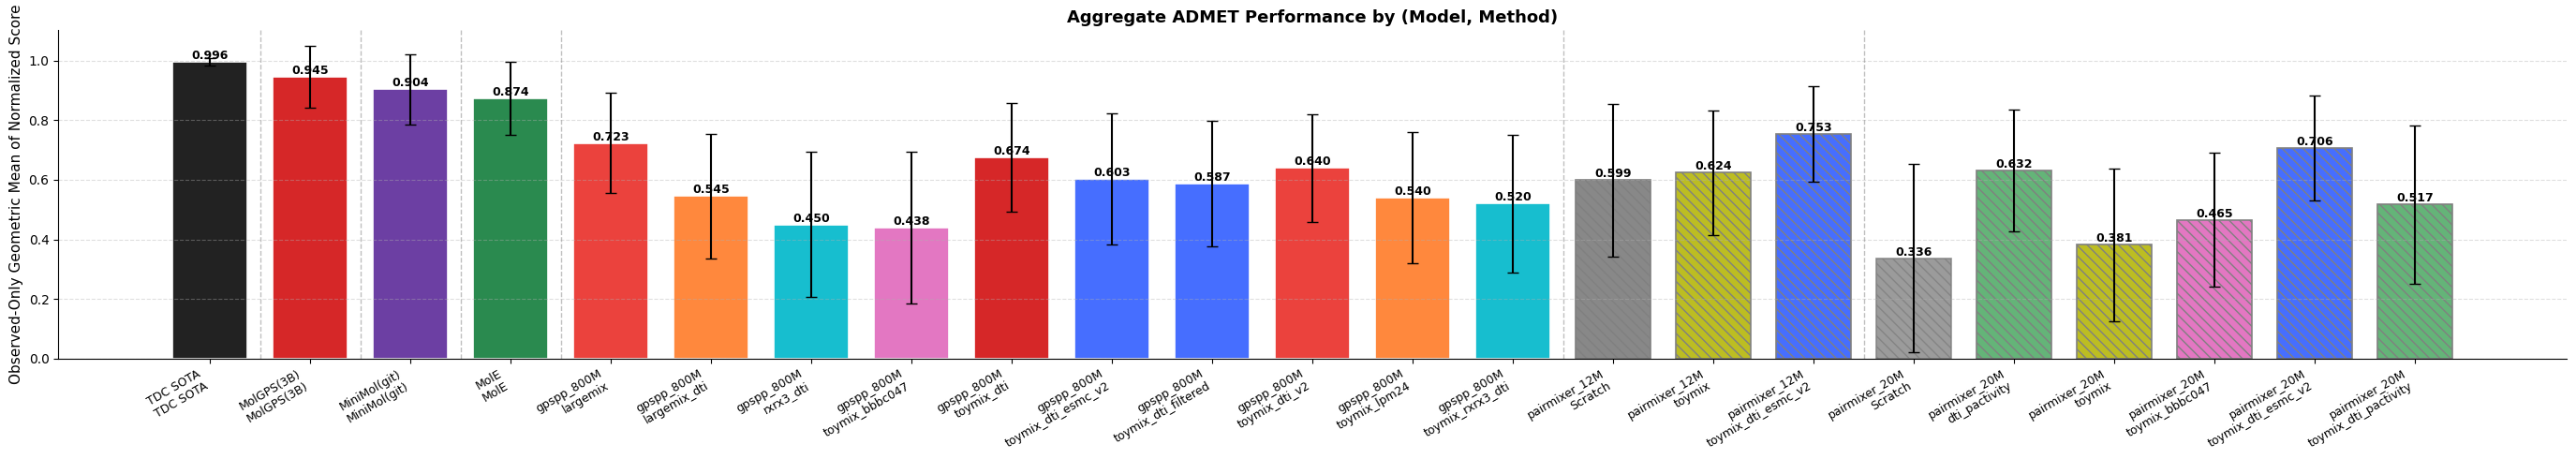

In [6]:
if len(agg_df) > 0 and agg_df['primary_metric'].notna().any():
    agg_df = agg_df.copy()

    # Create a combined label: "model / method"
    agg_df['model_method'] = agg_df['model_name'] + ' / ' + agg_df['method']

    # External baselines to overlay: (display_label, dict, bar_color)
    BASELINES = [
        ('TDC SOTA',     TDC_SOTA,     '#222222'),
        ('MolGPS(3B)',   MOLGPS,       '#d62728'),
        ('MiniMol(git)', MINIMOL_GIT,  '#6c3fa3'),
        ('MolE',         MOLE,         '#2a8a4f'),
    ]

    # Normalize within each task: map metric to [0, 1] where 1 = best.
    # All baselines and methods share a common [0, 1] scale per task.
    scores = []
    baseline_norms = {name: {} for name, _, _ in BASELINES}
    for task, group in agg_df.groupby('task'):
        direction = TASK_METRICS.get(task, (None, 'higher'))[1]
        vals = group['primary_metric'].astype(float)
        signed_baselines = {}
        for name, d, _ in BASELINES:
            entry = d.get(task)
            if entry is None:
                signed_baselines[name] = np.nan
                continue
            v = float(entry[0])
            signed_baselines[name] = -v if direction == 'lower' else v
        if direction == 'lower':
            vals = -vals

        pool = pd.concat(
            [vals] + [pd.Series([v]) for v in signed_baselines.values() if not np.isnan(v)]
        )
        vmin, vmax = pool.min(), pool.max()
        if vmax == vmin:
            norm = pd.Series(0.5, index=group.index)
            for name in signed_baselines:
                if not np.isnan(signed_baselines[name]):
                    baseline_norms[name][task] = 0.5
                else:
                    baseline_norms[name][task] = np.nan
        else:
            norm = (vals - vmin) / (vmax - vmin)
            for name, v in signed_baselines.items():
                baseline_norms[name][task] = (v - vmin) / (vmax - vmin) if not np.isnan(v) else np.nan
        scores.append(norm)
    agg_df['normalized_score'] = pd.concat(scores).astype(float)

    # Exclude (model, method) pairs with broken/diverged runs from geomean.
    _GEOMEAN_EXCLUDE = {
        ('gpspp_800M', 'dti'),
        ('gpspp_800M', 'toymix'),
        ('gpspp_800M', 'rxrx3'),
        ('gpspp_800M', 'Scratch'),
        ('gpspp_800M', 'toymix_rxrx3'),
    }
    agg_df = agg_df[~agg_df.set_index(['model_name', 'method']).index.isin(_GEOMEAN_EXCLUDE)].reset_index(drop=True)

    from scipy.stats import gmean

    TARGET_TASKS = [task for task in ADMET_TASK_ORDER if task in agg_df['task'].unique()]
    TOTAL_TASKS = len(TARGET_TASKS)
    EPSILON = 0.01  # smoothing floor for observed-only geomean

    def _observed_only_stats(task_scores):
        series = pd.Series(task_scores, copy=False)
        series = series[~series.index.duplicated(keep='last')].reindex(TARGET_TASKS)
        finite = series.dropna()
        if TOTAL_TASKS == 0 or len(finite) == 0:
            return {
                'geomean': np.nan,
                'std': np.nan,
                'count': 0,
                'missing': TOTAL_TASKS,
                'coverage': np.nan,
            }

        observed = finite.clip(lower=EPSILON)
        return {
            'geomean': float(gmean(observed.values)),
            'std': float(observed.std()) if len(observed) > 1 else 0.0,
            'count': int(len(finite)),
            'missing': int(TOTAL_TASKS - len(finite)),
            'coverage': float(len(finite) / TOTAL_TASKS),
        }

    agg = pd.DataFrame.from_dict(
        {
            key: _observed_only_stats(group.set_index('task')['normalized_score'])
            for key, group in agg_df.groupby(['model_name', 'method'])
        },
        orient='index',
    )
    agg.index = pd.MultiIndex.from_tuples(agg.index, names=['model_name', 'method'])

    def _baseline_stats(norm_map):
        series = pd.Series(norm_map).reindex(TARGET_TASKS)
        finite = series.dropna()
        if TOTAL_TASKS == 0 or len(finite) == 0:
            return np.nan, np.nan, 0, TOTAL_TASKS, np.nan

        observed = finite.clip(lower=EPSILON)
        geo = float(gmean(observed.values))
        std = float(observed.std()) if len(observed) > 1 else 0.0
        return geo, std, int(len(finite)), int(TOTAL_TASKS - len(finite)), float(len(finite) / TOTAL_TASKS)

    # Sort: by model order, then Scratch first, then FT alphabetically
    def sort_key(idx):
        model, method = idx
        model_order = MODELS_TO_SHOW.index(model) if model in MODELS_TO_SHOW else 999
        if method == 'Scratch':
            return (model_order, 0, method)
        return (model_order, 1, method)
    agg = agg.loc[sorted(agg.index, key=sort_key)]

    # Prepend baselines
    plot_index = [(name, name) for name, _, _ in BASELINES] + list(agg.index)
    baseline_stats = [_baseline_stats(baseline_norms[name]) for name, _, _ in BASELINES]
    plot_means = [s[0] for s in baseline_stats] + list(agg['geomean'].values)
    plot_stds = [s[1] for s in baseline_stats] + list(agg['std'].values)
    plot_counts = [s[2] for s in baseline_stats] + list(agg['count'].values)
    plot_missing = [s[3] for s in baseline_stats] + list(agg['missing'].values)
    plot_coverage = [s[4] for s in baseline_stats] + list(agg['coverage'].values)

    labels = [f'{m}\n{meth}' for m, meth in plot_index]

    note = (
        'Observed-only geometric mean per (model, method): '
        f'use the observed finite task scores only (^(1/n_observed)); zero scores are floored to EPSILON={EPSILON:.2f}. '
        f'Coverage is still reported across {TOTAL_TASKS} ADMET tasks.'
    )
    print(note)
    gmean_table = pd.DataFrame(
        {
            'geomean': plot_means,
            'std': plot_stds,
            'count': plot_counts,
            'missing': plot_missing,
            'coverage': plot_coverage,
        },
        index=pd.MultiIndex.from_tuples(plot_index, names=['model_name', 'method']),
    )
    print(gmean_table.to_string(float_format=lambda v: f'{v:.4f}'))

    method_colors = METHOD_COLORS
    model_hatches = {m: FAMILY_HATCHES.get(infer_model_family(m), 'xx') for m in MODELS_TO_SHOW}
    baseline_colors = {name: color for name, _, color in BASELINES}

    fig, ax = plt.subplots(figsize=(max(10, len(plot_index) * 1.2), 5))
    x = np.arange(len(plot_index))
    for i, (model, method) in enumerate(plot_index):
        mean_v = plot_means[i]
        std_v = plot_stds[i]
        coverage_v = plot_coverage[i]
        if model in baseline_colors:
            color = baseline_colors[model]
            hatch = ''
            alpha = 1.0
        else:
            color = method_colors.get(method, '#466eff')
            hatch = model_hatches.get(model, '')
            alpha = 1.0 if np.isnan(coverage_v) else 0.65 + 0.35 * coverage_v
        ax.bar(i, mean_v, yerr=std_v, color=color, hatch=hatch,
               edgecolor='white' if not hatch else 'grey', alpha=alpha,
               capsize=4, linewidth=1.2, width=0.75)
        if not np.isnan(mean_v):
            ax.text(i, mean_v, f'{mean_v:.3f}', ha='center', va='bottom',
                    fontsize=9, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Observed-Only Geometric Mean of Normalized Score', fontsize=11)
    ax.set_title('Aggregate ADMET Performance by (Model, Method)', fontsize=13, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, axis='y', ls='--', alpha=0.4)

    prev_model = None
    for i, (model, _) in enumerate(plot_index):
        if prev_model is not None and model != prev_model:
            ax.axvline(x=i - 0.5, color='grey', linewidth=1, linestyle='--', alpha=0.5)
        prev_model = model

    plt.tight_layout()
    plt.show()
else:
    print('No ADMET results to aggregate.')


Selected: model=['pairmixer_12M', 'pairmixer_20M'], method=['scratch', 'Scratch', 'toymix', 'dti_pactivity', 'toymix', 'toymix_dti_esmc_v2', 'toymix_bbbc047', 'toymix_dti_pactivity']
                                    geomean    std  count  missing  coverage
model_name    method                                                        
TDC SOTA      TDC SOTA               0.9963 0.0119     22        0    1.0000
MolGPS(3B)    MolGPS(3B)             0.9452 0.1041     22        0    1.0000
MiniMol(git)  MiniMol(git)           0.9041 0.1180     22        0    1.0000
MolE          MolE                   0.8742 0.1224     22        0    1.0000
pairmixer_12M Scratch                0.5989 0.2569     22        0    1.0000
              toymix                 0.6240 0.2088     22        0    1.0000
              toymix_dti_esmc_v2     0.7531 0.1612     22        0    1.0000
pairmixer_20M Scratch                0.3361 0.3155     12       10    0.5455
              dti_pactivity          0.6319 0.2

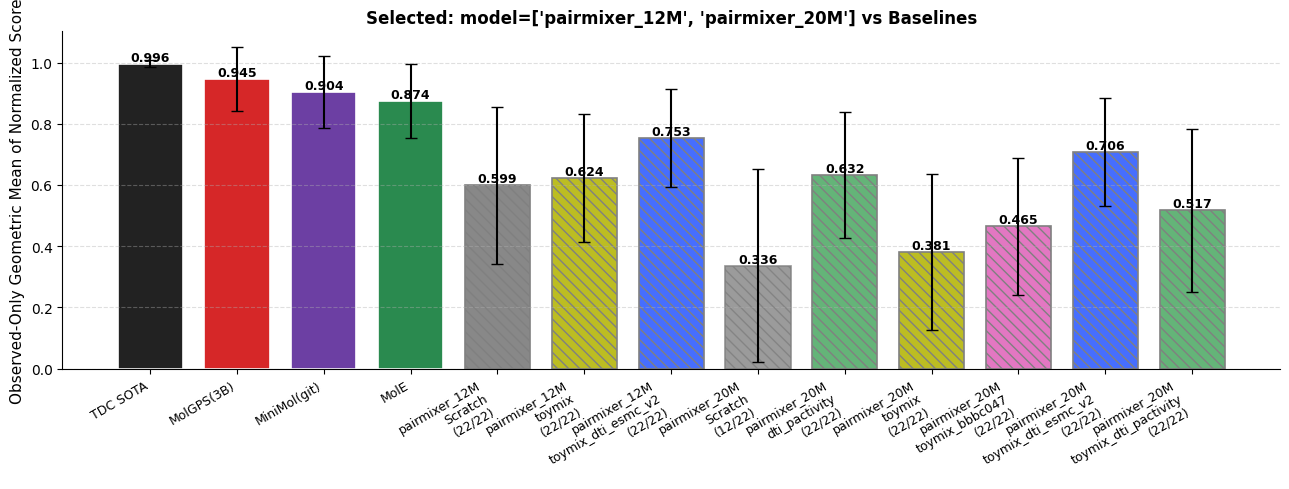

In [7]:
# === Filtered view: reuse geomean from the previous cell ===
# Each field accepts: None (keep all), a single string, or a list of strings.
# SELECTED_MODEL = 'gpspp_800M'
# SELECTED_METHOD = ['scratch', 'largemix', 'toymix','toymix_dti_esmc_v2', 'toymix_bbbc047', 'toymix_lpm24']
SELECTED_MODEL = ['pairmixer_12M', 'pairmixer_20M']
SELECTED_METHOD = ['scratch', 'Scratch', 'toymix', 'dti_pactivity', 'toymix', 'toymix_dti_esmc_v2', 'toymix_bbbc047', 'toymix_dti_pactivity']

def _as_list(x):
    if x is None:
        return None
    return [x] if isinstance(x, str) else list(x)

_models = _as_list(SELECTED_MODEL)
_methods = _as_list(SELECTED_METHOD)

baseline_names = [name for name, _, _ in BASELINES]
baseline_colors = {name: color for name, _, color in BASELINES}

# Pick rows from the previously computed gmean_table: always keep baselines,
# filter (model, method) pairs by the selections above.
keep = []
for (model, method) in gmean_table.index:
    if model in baseline_names:
        keep.append(True)
        continue
    if _models is not None and model not in _models:
        keep.append(False); continue
    if _methods is not None and method not in _methods:
        keep.append(False); continue
    keep.append(True)
sel_table = gmean_table[keep]

print(f'Selected: model={SELECTED_MODEL!r}, method={SELECTED_METHOD!r}')
print(sel_table.to_string(float_format=lambda v: f'{v:.4f}'))

# Plot: baselines first (solid color), then selected method bars (hatched by family)
labels, values, stds, colors, hatches, alphas = [], [], [], [], [], []
for (model, method), row in sel_table.iterrows():
    if model in baseline_names:
        labels.append(model)
        colors.append(baseline_colors[model])
        hatches.append('')
        alphas.append(1.0)
    else:
        labels.append(f'{model}\n{method}\n({int(row["count"] )}/{TOTAL_TASKS})')
        colors.append(METHOD_COLORS.get(method, '#466eff'))
        fam = infer_model_family(model)
        hatches.append(FAMILY_HATCHES.get(fam, 'xx'))
        alphas.append(1.0 if np.isnan(row['coverage']) else 0.65 + 0.35 * row['coverage'])
    values.append(row['geomean'])
    stds.append(row['std'])

fig, ax = plt.subplots(figsize=(max(6, len(labels) * 1.0), 5))
x = np.arange(len(labels))
for i in range(len(labels)):
    ax.bar(x[i], values[i], yerr=stds[i], color=colors[i], hatch=hatches[i], alpha=alphas[i],
           edgecolor='white' if not hatches[i] else 'grey',
           capsize=4, linewidth=1.2, width=0.75)
    if not np.isnan(values[i]):
        ax.text(x[i], values[i], f'{values[i]:.3f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Observed-Only Geometric Mean of Normalized Score', fontsize=11)
ax.set_title(
    f'Selected: model={SELECTED_MODEL} vs Baselines',
    fontsize=12, fontweight='bold',
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, axis='y', ls='--', alpha=0.4)
plt.tight_layout()
plt.show()


### Per-task comparison: SOTA vs selected methods

5x6 grid where each row is an ADMET category. TDC SOTA shown as a thick black horizontal line.

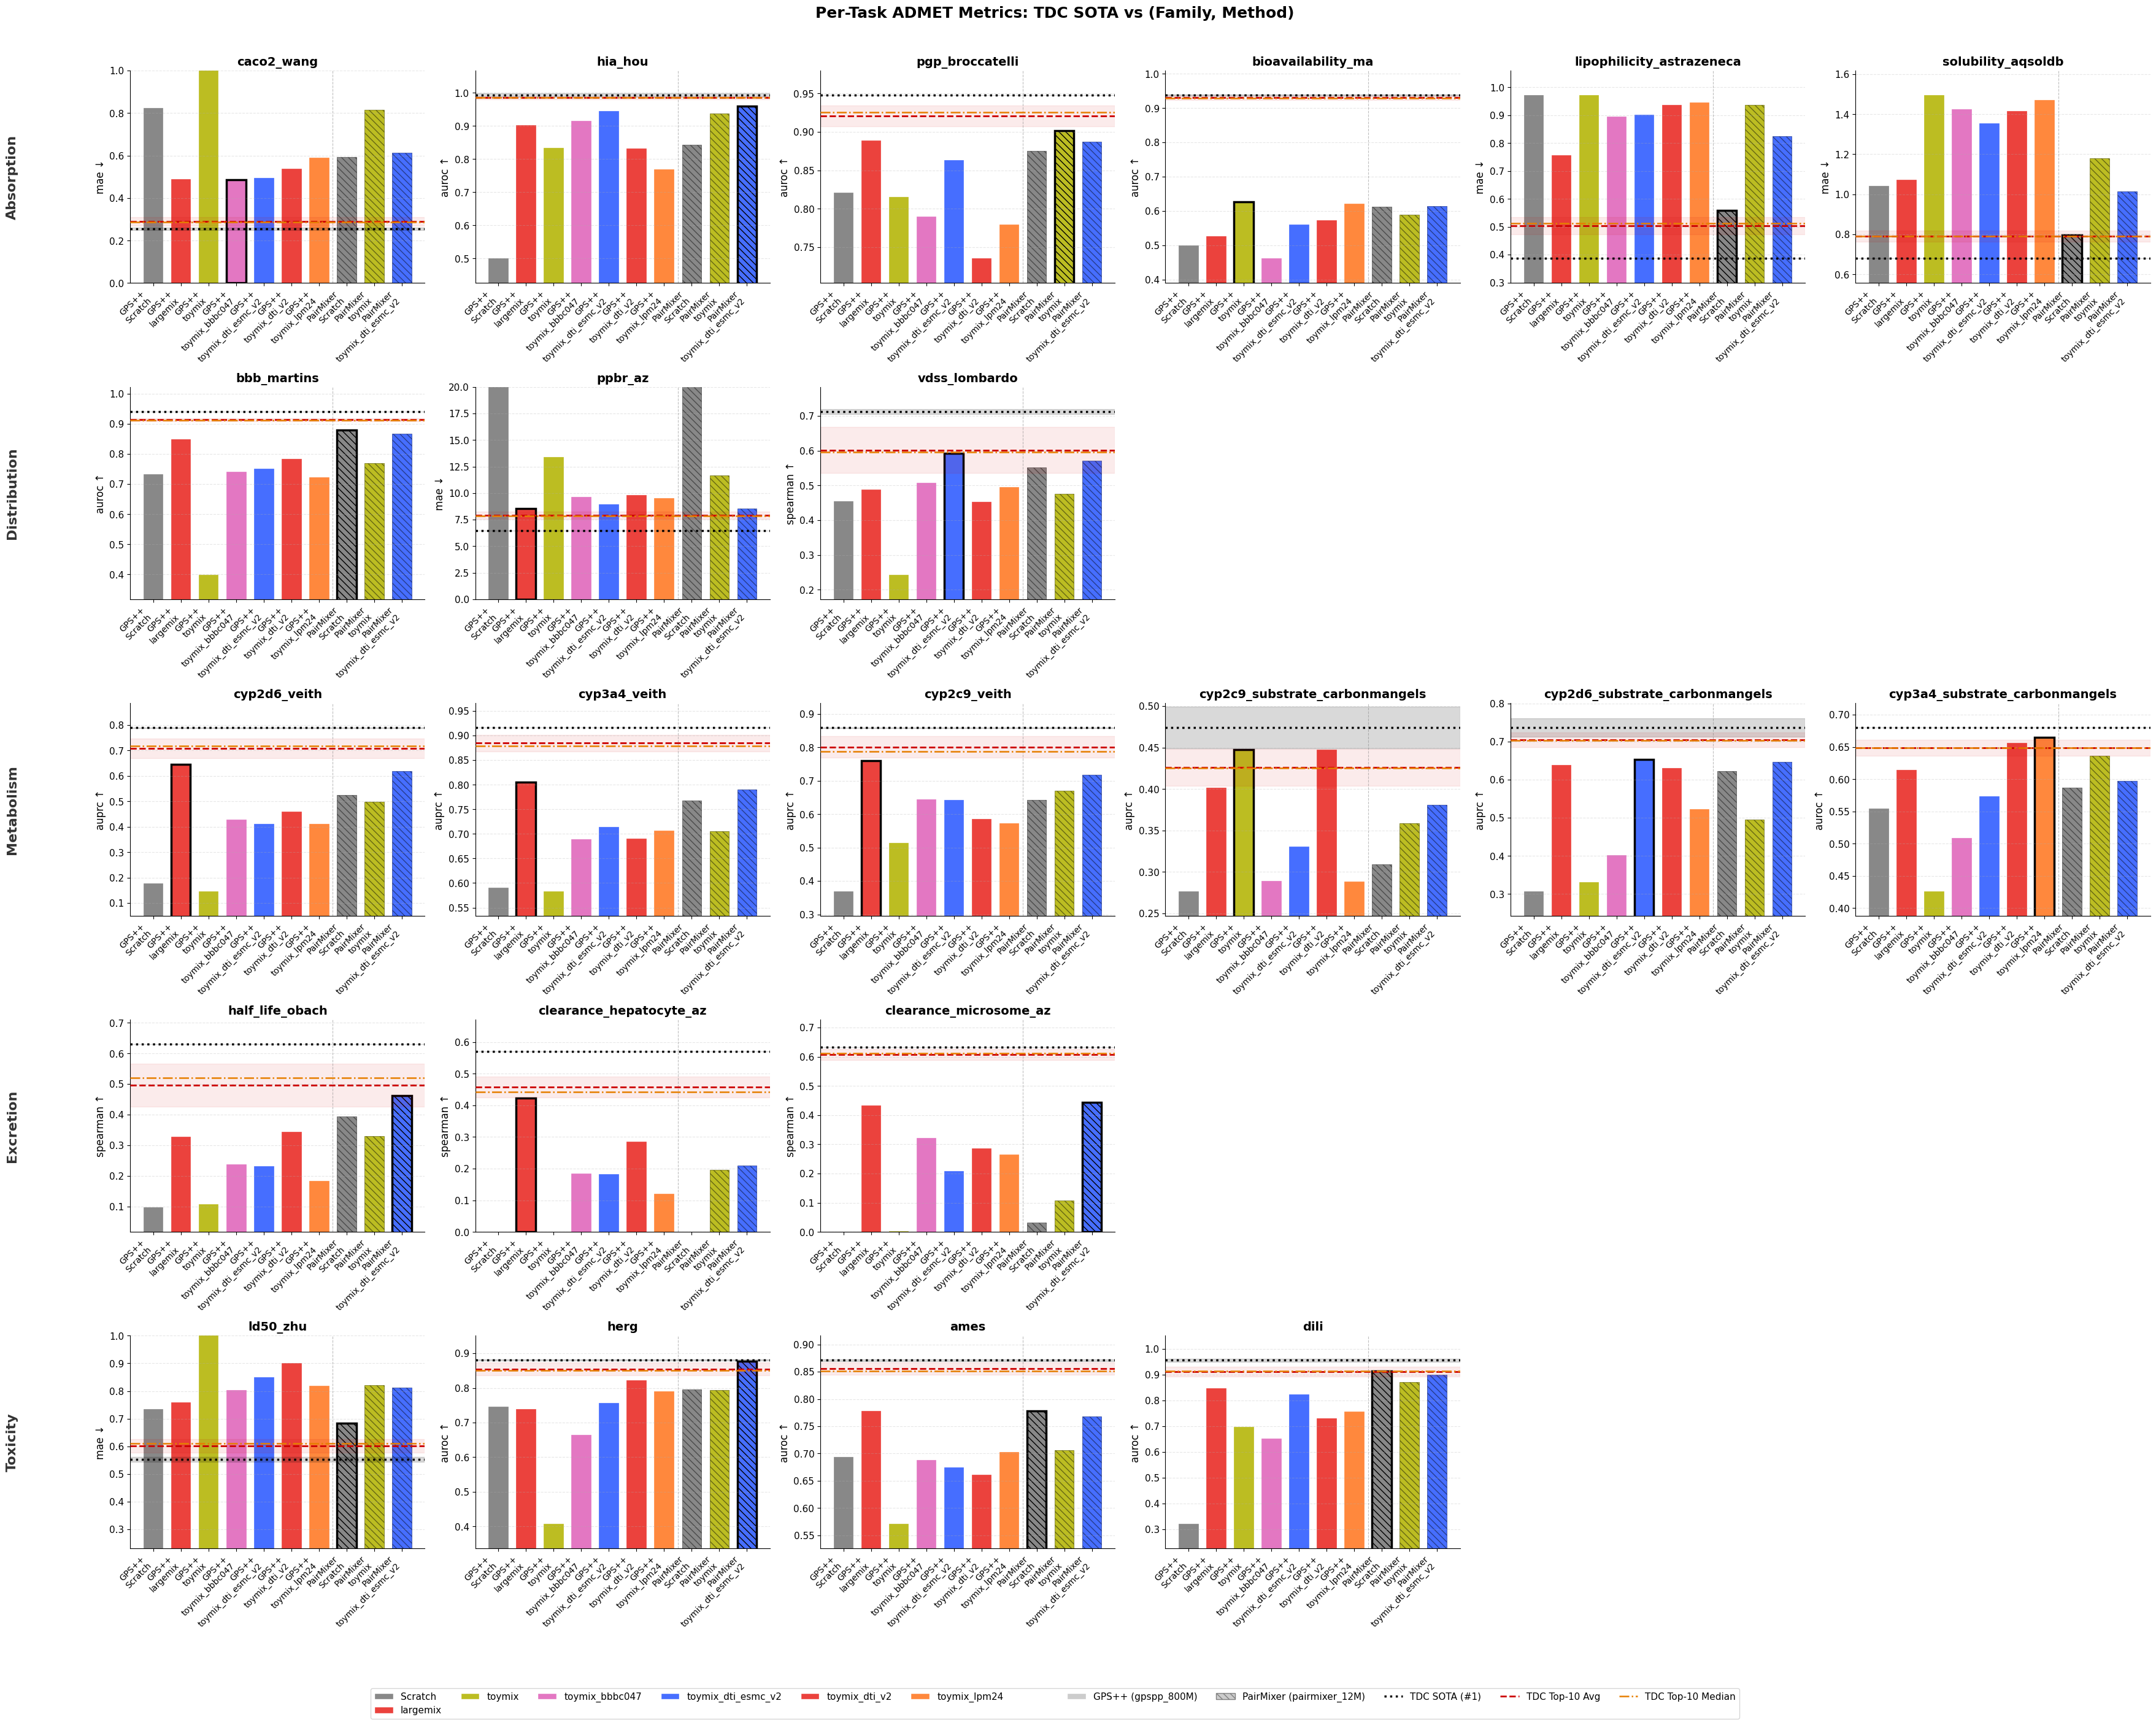


Pairs shown: 10
Default variants: {'GPS++': 'gpspp_800M', 'PairMixer': 'pairmixer_12M'}
TDC SOTA (#1): dotted black horizontal line with ±std shading
TDC Top-10 Avg: dashed red horizontal line with ±std shading
TDC Top-10 Median: dash-dot orange horizontal line
Error bars: ± std across runs for each (model, method) pair
Best across all (family, method): thick black border

  Win Count Summary: tasks where each method beats the baseline


Model / Method,Tasks,Beat Top-10 Avg,Beat Top-10 Median,Beat Scratch
GPS++ / Scratch,22,0,0,-
GPS++ / largemix,22,0,0,17
GPS++ / toymix,22,1,1,7
GPS++ / toymix_bbbc047,22,0,0,8
GPS++ / toymix_dti_esmc_v2,22,0,0,14
GPS++ / toymix_dti_v2,22,2,2,14
GPS++ / toymix_lpm24,22,1,1,13
PairMixer / Scratch,22,1,1,-
PairMixer / toymix,22,0,0,15
PairMixer / toymix_dti_esmc_v2,22,1,1,19



Model / Method                      Tasks   vs Avg   vs Med  vs Scratch
----------------------------------------------------------------------
  GPS++ / Scratch                      22        0        0           -
  GPS++ / largemix                     22        0        0          17
  GPS++ / toymix                       22        1        1           7
  GPS++ / toymix_bbbc047               22        0        0           8
  GPS++ / toymix_dti_esmc_v2           22        0        0          14
  GPS++ / toymix_dti_v2                22        2        2          14
  GPS++ / toymix_lpm24                 22        1        1          13
  PairMixer / Scratch                  22        1        1           -
  PairMixer / toymix                   22        0        0          15
  PairMixer / toymix_dti_esmc_v2       22        1        1          19


In [8]:
# === Config: select which methods to show ===
# SELECTED_METHODS = ['Scratch', 'toymix', 'toymix_dti']
# SELECTED_METHODS = ['Scratch', 'toymix', 'largemix', 'toymix_rxrx3', 'toymix_dti', 'toymix_dti_filtered', 'toymix_bbbc047', 'largemix_dti', 'toymix_dti_v2', 'toymix_dti_esmc_v2', 'toymix_lpm24']
SELECTED_METHODS = ['Scratch', 'toymix', 'largemix', 'toymix_bbbc047', 'toymix_dti_v2', 'toymix_dti_esmc_v2', 'toymix_lpm24']

# Per-task y-axis overrides: {task: (ymin, ymax)} — set either to None to auto-compute
TASK_YLIM_OVERRIDES = {
    'caco2_wang': (None, 1),
    'ppbr_az': (None, 20),
    'ld50_zhu': (None, 1),
}

# Uses DEFAULT_VARIANT (defined in cell 1) — one representative model per family.
# Legend is collapsed to family level.
SELECTED_MODELS = list(DEFAULT_VARIANT.values())

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgb

def _darken(c, f=0.55):
    r, g, b = to_rgb(c)
    return (r * f, g * f, b * f)

if len(admet_df) > 0 and admet_df['primary_metric'].notna().any():
    # Group by (task, model_name, method) — compute mean AND std
    task_model_method_stats = admet_df.groupby(['task', 'model_name', 'method'])['primary_metric'].agg(['mean', 'std', 'count'])
    task_model_method_means = task_model_method_stats['mean']
    task_model_method_stds = task_model_method_stats['std'].fillna(0)

    # Build the list of (model, method) pairs to plot
    all_available = sorted(admet_df[['model_name', 'method']].drop_duplicates().apply(tuple, axis=1))
    pairs_to_plot = [(m, meth) for m, meth in all_available if m in SELECTED_MODELS]
    if SELECTED_METHODS is not None:
        pairs_to_plot = [(m, meth) for m, meth in pairs_to_plot if meth in SELECTED_METHODS]

    # Sort: by family order (GPS++ -> Pairformer -> PairMixer), Scratch first within each model
    _FAMILY_ORDER = {'GPS++': 0, 'Pairformer': 1, 'PairMixer': 2}
    def pair_sort_key(pair):
        model, method = pair
        fam_order = _FAMILY_ORDER.get(infer_model_family(model), 999)
        return (fam_order, 0 if method == 'Scratch' else 1, method)
    pairs_to_plot = sorted(pairs_to_plot, key=pair_sort_key)

    # Short labels for x-axis: "family\nmethod"
    short_labels = [f'{infer_model_family(m)}\n{meth}' for m, meth in pairs_to_plot]

    n_bars = len(pairs_to_plot)

    # Color palette: same method = same color; family distinguished by hatch
    method_colors = METHOD_COLORS
    colors = [method_colors.get(meth, '#466eff') for _, meth in pairs_to_plot]
    hatches = [FAMILY_HATCHES.get(infer_model_family(m), '') for m, _ in pairs_to_plot]

    # Layout: 5 rows (one per ADMET category) x 6 cols
    CATEGORIES_ORDER = ['Absorption', 'Distribution', 'Metabolism', 'Excretion', 'Toxicity']
    CATEGORY_TASKS = {cat: [t for t in ADMET_TASK_ORDER if TASK_CATEGORY[t] == cat] for cat in CATEGORIES_ORDER}

    fig, axes = plt.subplots(5, 6, figsize=(max(36, n_bars * 2), 28))
    x_pos = np.arange(n_bars)

    # --- Track wins against TDC top-10 average ---
    wins_vs_top10 = {}  # (model, method) -> number of tasks beating top-10 avg
    for pair in pairs_to_plot:
        wins_vs_top10[pair] = 0
    total_comparable_tasks = 0

    for row_idx, cat in enumerate(CATEGORIES_ORDER):
        tasks_in_cat = CATEGORY_TASKS[cat]
        for col_idx in range(6):
            ax = axes[row_idx, col_idx]

            if col_idx >= len(tasks_in_cat):
                ax.set_visible(False)
                continue

            task = tasks_in_cat[col_idx]
            metric_name, direction = TASK_METRICS[task]
            arrow = '\u2191' if direction == 'higher' else '\u2193'

            # Collect mean and std for each (model, method) pair
            vals = []
            errs = []
            for model, method in pairs_to_plot:
                try:
                    vals.append(task_model_method_means.loc[(task, model, method)])
                except KeyError:
                    vals.append(np.nan)
                try:
                    errs.append(task_model_method_stds.loc[(task, model, method)])
                except KeyError:
                    errs.append(0)
            vals = np.array(vals, dtype=float)
            errs = np.array(errs, dtype=float)

            sota_mean = None
            if task in TDC_SOTA:
                sota_mean = TDC_SOTA[task][0]

            top10_mean = None
            top10_std = None
            if task in TDC_TOP10_AVG:
                top10_mean, top10_std = TDC_TOP10_AVG[task]

            # Count wins vs TDC top-10 average
            if top10_mean is not None:
                task_counted = False
                for idx_p, (v, pair) in enumerate(zip(vals, pairs_to_plot)):
                    if not np.isfinite(v):
                        continue
                    if not task_counted:
                        task_counted = True
                    beats = (direction == 'lower' and v <= top10_mean) or \
                            (direction == 'higher' and v >= top10_mean)
                    if beats:
                        wins_vs_top10[pair] += 1
                if task_counted:
                    total_comparable_tasks += 1

            # Find best among all pairs
            finite_mask = np.isfinite(vals)
            best_idx = None
            if any(finite_mask):
                if direction == 'lower':
                    best_idx = np.where(finite_mask, vals, np.inf).argmin()
                else:
                    best_idx = np.where(finite_mask, vals, -np.inf).argmax()

            # Plot bars with error bars
            for i, (v, e, c, h) in enumerate(zip(vals, errs, colors, hatches)):
                if np.isfinite(v):
                    err_val = e if np.isfinite(e) and e > 0 else None
                    if i == best_idx:
                        ax.bar(i, v, yerr=err_val, color=c, hatch=h,
                               edgecolor='black', linewidth=2.5, width=0.7,
                               capsize=3, error_kw={'linewidth': 1.2})
                    else:
                        ec = _darken(c) if h else c
                        ax.bar(i, v, yerr=err_val, color=c, hatch=h,
                               edgecolor=ec, linewidth=0.5, width=0.7,
                               capsize=3, error_kw={'linewidth': 1.0, 'color': '#555'})

            # SOTA as dotted black horizontal line with +/-std shading
            if sota_mean is not None:
                _, sota_std, sota_method = TDC_SOTA[task]
                ax.axhline(y=sota_mean, color='black', linewidth=2.5, linestyle=':', zorder=5)
                ax.axhspan(sota_mean - sota_std, sota_mean + sota_std, alpha=0.15, color='black', zorder=1)

            # TDC top-10 average as dashed red line with +/-std shading
            if top10_mean is not None:
                ax.axhline(y=top10_mean, color='#cc0000', linewidth=2.0, linestyle='--', zorder=4)
                ax.axhspan(top10_mean - top10_std, top10_mean + top10_std,
                           alpha=0.08, color='#cc0000', zorder=1)

            # TDC top-10 median as dash-dot orange line
            top10_median = TDC_TOP10_MEDIAN.get(task)
            if top10_median is not None:
                ax.axhline(y=top10_median, color='#e67e00', linewidth=1.8, linestyle='-.', zorder=4)

            # Adjust y-axis limits
            all_finite = vals[np.isfinite(vals)].tolist()
            if sota_mean is not None:
                all_finite.append(sota_mean)
            if top10_mean is not None:
                all_finite.append(top10_mean)
            if top10_median is not None:
                all_finite.append(top10_median)
            if len(all_finite) >= 1:
                vmin, vmax = min(all_finite), max(all_finite)
                span = vmax - vmin if vmax > vmin else vmax * 0.1
                padding = span * 0.15
                ylo = max(0, vmin - padding)
                yhi = vmax + padding
                if task in TASK_YLIM_OVERRIDES:
                    override_lo, override_hi = TASK_YLIM_OVERRIDES[task]
                    if override_lo is not None:
                        ylo = override_lo
                    if override_hi is not None:
                        yhi = override_hi
                ax.set_ylim(ylo, yhi)

            ax.set_xticks(x_pos)
            ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=10)
            ax.set_title(f'{task}', fontsize=14, fontweight='bold')
            ax.set_ylabel(f'{metric_name} {arrow}', fontsize=12)
            ax.tick_params(axis='y', labelsize=11)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.grid(True, axis='y', ls='--', alpha=0.3)

            # Vertical separator between families
            prev_family = None
            for i, (model, _) in enumerate(pairs_to_plot):
                fam = infer_model_family(model)
                if prev_family is not None and fam != prev_family:
                    ax.axvline(x=i - 0.5, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)
                prev_family = fam

            if col_idx == 0:
                ax.annotate(cat, xy=(-0.4, 0.5), xycoords='axes fraction',
                            fontsize=16, fontweight='bold', color='#333',
                            ha='center', va='center', rotation=90)

    # Legend: pretrain dataset colors + family hatching + SOTA line + top-10 avg line
    legend_handles = []
    # Pretrain dataset colors
    seen_methods = []
    for _, meth in pairs_to_plot:
        if meth not in seen_methods:
            seen_methods.append(meth)
    for meth in seen_methods:
        legend_handles.append(Patch(facecolor=method_colors.get(meth, '#466eff'),
                                    edgecolor='white', label=meth))
    # Separator
    legend_handles.append(Patch(facecolor='none', edgecolor='none', label=''))
    # Family hatching (one entry per family, showing the selected variant)
    for fam in ['GPS++', 'Pairformer', 'PairMixer']:
        variant = DEFAULT_VARIANT.get(fam)
        if variant is None:
            continue
        h = FAMILY_HATCHES.get(fam, '')
        label = f'{fam} ({variant})'
        legend_handles.append(Patch(facecolor='#cccccc', hatch=h,
                                    edgecolor='grey' if h else 'white', label=label))
    legend_handles.append(Line2D([0], [0], color='black', linewidth=2.5, linestyle=':', label='TDC SOTA (#1)'))
    legend_handles.append(Line2D([0], [0], color='#cc0000', linewidth=2.0, linestyle='--', label='TDC Top-10 Avg'))
    legend_handles.append(Line2D([0], [0], color='#e67e00', linewidth=1.8, linestyle='-.', label='TDC Top-10 Median'))
    fig.legend(handles=legend_handles, loc='lower center', ncol=min(len(legend_handles), 12), fontsize=11, bbox_to_anchor=(0.5, -0.02), frameon=True)

    fig.suptitle('Per-Task ADMET Metrics: TDC SOTA vs (Family, Method)', fontsize=18, fontweight='bold')
    plt.tight_layout(rect=[0.03, 0.03, 1, 0.97])
    plt.show()

    print(f"\nPairs shown: {len(pairs_to_plot)}")
    print(f"Default variants: {DEFAULT_VARIANT}")
    print("TDC SOTA (#1): dotted black horizontal line with \u00b1std shading")
    print("TDC Top-10 Avg: dashed red horizontal line with \u00b1std shading")
    print("TDC Top-10 Median: dash-dot orange horizontal line")
    print("Error bars: \u00b1 std across runs for each (model, method) pair")
    print("Best across all (family, method): thick black border")

    # --- Comparison table: wins vs TDC top-10 avg, median, and Scratch ---
    if total_comparable_tasks > 0:
        # Collect Scratch values per task (average across all models)
        scratch_vals = {}
        for task in ADMET_TASK_ORDER:
            scratch_rows = admet_df[(admet_df['task'] == task) & (admet_df['method'] == 'Scratch')]
            if len(scratch_rows) > 0 and scratch_rows['primary_metric'].notna().any():
                scratch_vals[task] = scratch_rows['primary_metric'].mean()

        # Build comparison data for each (model, method) pair
        comp_rows = []
        for model, method in pairs_to_plot:
            fam = infer_model_family(model)
            label = f"{fam} / {method}"
            wins_avg = 0
            wins_med = 0
            wins_scratch = 0
            n_tasks = 0

            for task in ADMET_TASK_ORDER:
                try:
                    val = task_model_method_means.loc[(task, model, method)]
                except KeyError:
                    continue
                if not np.isfinite(val):
                    continue

                direction = TASK_METRICS.get(task, (None, 'higher'))[1]
                n_tasks += 1

                # vs TDC top-10 average
                if task in TDC_TOP10_AVG:
                    t10_mean, _ = TDC_TOP10_AVG[task]
                    if (direction == 'lower' and val <= t10_mean) or \
                       (direction == 'higher' and val >= t10_mean):
                        wins_avg += 1

                # vs TDC top-10 median
                if task in TDC_TOP10_MEDIAN:
                    t10_med = TDC_TOP10_MEDIAN[task]
                    if (direction == 'lower' and val <= t10_med) or \
                       (direction == 'higher' and val >= t10_med):
                        wins_med += 1

                # vs Scratch (same model)
                if task in scratch_vals:
                    sv = scratch_vals[task]
                    # For scratch comparison: check if this method is better than scratch
                    if method != 'Scratch':
                        if (direction == 'lower' and val < sv) or \
                           (direction == 'higher' and val > sv):
                            wins_scratch += 1

            comp_rows.append({
                'label': label,
                'model': model,
                'method': method,
                'n_tasks': n_tasks,
                'vs_top10_avg': wins_avg,
                'vs_top10_med': wins_med,
                'vs_scratch': wins_scratch if method != 'Scratch' else '-',
            })

        # Display as styled DataFrame table
        comp_df = pd.DataFrame(comp_rows)
        comp_df = comp_df.rename(columns={
            'label': 'Model / Method',
            'n_tasks': 'Tasks',
            'vs_top10_avg': 'Beat Top-10 Avg',
            'vs_top10_med': 'Beat Top-10 Median',
            'vs_scratch': 'Beat Scratch',
        })
        comp_df = comp_df[['Model / Method', 'Tasks', 'Beat Top-10 Avg', 'Beat Top-10 Median', 'Beat Scratch']]

        print(f"\n{'='*80}")
        print("  Win Count Summary: tasks where each method beats the baseline")
        print(f"{'='*80}")

        styled_comp = (
            comp_df.style
            .set_caption('Tasks beating TDC Top-10 Average / Median / Scratch baseline')
            .set_table_styles([
                {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
                {'selector': 'td', 'props': [('text-align', 'center')]},
                {'selector': 'td:first-child', 'props': [('text-align', 'left')]},
            ])
            .hide(axis='index')
        )
        display(styled_comp)

        # Also print text version
        print(f"\n{'Model / Method':35s} {'Tasks':>5s}  {'vs Avg':>7s}  {'vs Med':>7s}  {'vs Scratch':>10s}")
        print("-" * 70)
        for _, row in comp_df.iterrows():
            print(f"  {row['Model / Method']:33s} {row['Tasks']:>5}  {row['Beat Top-10 Avg']:>7}  {row['Beat Top-10 Median']:>7}  {str(row['Beat Scratch']):>10}")
else:
    print("No ADMET results to plot.")


## Polaris ADME-Fang

Six single-task regression benchmarks from the Polaris `biogen/adme-fang-v1` suite.
Primary metric: **Pearson r** (higher is better).

In [9]:
_FANG_TASKS = [
    'adme_fang_hclint', 'adme_fang_rclint', 'adme_fang_perm',
    'adme_fang_hppb', 'adme_fang_rppb', 'adme_fang_solu',
]
_FANG_LABELS = {
    'adme_fang_hclint': 'Human CLint',
    'adme_fang_rclint': 'Rat CLint',
    'adme_fang_perm':   'Permeability',
    'adme_fang_hppb':   'Human PPB',
    'adme_fang_rppb':   'Rat PPB',
    'adme_fang_solu':   'Solubility',
}
_FANG_METRIC_COLS = [
    ('pearsonr',  'pearsonr \u2191',  'higher', True),   # main metric
    ('spearmanr', 'spearmanr \u2191', 'higher', False),
    ('r2_score',  'r2 \u2191',        'higher', False),
    ('mae',       'mae \u2193',       'lower',  False),
    ('mse',       'mse \u2193',       'lower',  False),
]

# Polaris leaderboard SOTA (pearsonr, rank #1). Source: polarishub.io, 2026-04.
_FANG_SOTA = {
    'adme_fang_perm':   ('(unnamed)',  0.725),
    'adme_fang_hppb':   ('MolGPS-ens', 0.886),
    'adme_fang_rppb':   ('MolGPS-ens', 0.892),
    'adme_fang_solu':   ('MolGPS-ens', 0.781),
}

_fang_df = df[df['task'].isin(_FANG_TASKS)].copy()
_fang_df['method'] = _fang_df.apply(build_method_label, axis=1)
_fang_df['model_name'] = _fang_df.apply(infer_model_name, axis=1)
_fang_df = _fang_df[_fang_df['model_name'] != 'pairmixer_20M']

if len(_fang_df) > 0:
    _rows = []
    for _task in _FANG_TASKS:
        _label = _FANG_LABELS[_task]
        _tdf = _fang_df[_fang_df['task'] == _task]

        # SOTA row
        if _task in _FANG_SOTA:
            _sname, _sval = _FANG_SOTA[_task]
            _sr = {'Task': _label, 'Model': _sname + ' (SOTA)'}
            for _msuf, _mdisp, _, _is_main in _FANG_METRIC_COLS:
                _sr[_mdisp] = f'{_sval:.3f}' if _msuf == 'pearsonr' else ''
            _rows.append(_sr)

        if len(_tdf) == 0:
            _row = {'Task': _label, 'Model': '(no results)'}
            for _, _mdisp, _, _ in _FANG_METRIC_COLS:
                _row[_mdisp] = '-'
            _rows.append(_row)
        else:
            for _, _r in _tdf.iterrows():
                _mname = _r['model_name']
                _method = _r['method']
                _row = {'Task': _label, 'Model': f'{_mname} / {_method}'}
                for _msuf, _mdisp, _, _ in _FANG_METRIC_COLS:
                    _col = [c for c in _tdf.columns
                            if _task in c and f'/{_msuf}/' in c and 'test' in c]
                    _val = pd.to_numeric(_r[_col[0]], errors='coerce') if _col else np.nan
                    _row[_mdisp] = f'{_val:.4f}' if pd.notna(_val) else '-'
                _rows.append(_row)

    _result = pd.DataFrame(_rows)
    _metric_cols = [d for _, d, _, _ in _FANG_METRIC_COLS]
    _main_col = [d for _, d, _, m in _FANG_METRIC_COLS if m][0]

    # Multi-row index: group by Task
    _result = _result.set_index(['Task', 'Model'])

    def _style_fang(_s):
        _styles = pd.DataFrame('', index=_s.index, columns=_s.columns)
        # SOTA rows: main metric bold + underlined, rest grey
        for _idx in _s.index:
            if '(SOTA)' in str(_idx[1]):
                _styles.loc[_idx] = 'background-color: #f0f0f0; color: #555; font-size: 0.9em'
                if _main_col in _styles.columns:
                    _styles.loc[_idx, _main_col] = 'background-color: #f0f0f0; font-weight: bold; text-decoration: underline'
        return _styles

    # Compute row-level border positions for task boundaries (full-row via set_table_styles)
    _row_styles = [
        {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center')]},
        {'selector': 'th.row_heading', 'props': [('text-align', 'left')]},
    ]
    _prev_task = None
    for _i, _idx in enumerate(_result.index):
        _cur_task = _idx[0]
        if _prev_task is not None and _cur_task != _prev_task:
            _row_styles.append({
                'selector': f'tbody tr:nth-child({_i + 1})',
                'props': 'border-top: 2px solid #999',
            })
        _prev_task = _cur_task

    _styled = (
        _result.style
        .apply(_style_fang, axis=None)
        .set_caption('ADME Fang (Polaris) \u2014 All Metrics (main: pearsonr, underlined)')
        .set_table_styles(_row_styles)
    )
    display(_styled)

    # LaTeX output
    print('\n% LaTeX (copy-paste for paper):')
    print(_result.to_latex(multirow=True, escape=False))
else:
    print('No ADME Fang results yet.')


% LaTeX (copy-paste for paper):
\begin{tabular}{lllllll}
\toprule
 &  & pearsonr ↑ & spearmanr ↑ & r2 ↑ & mae ↓ & mse ↓ \\
Task & Model &  &  &  &  &  \\
\midrule
\multirow[t]{3}{*}{Human CLint} & pairmixer_12M / Scratch & 0.5820 & 0.6016 & 0.2617 & 0.3984 & 0.2871 \\
 & pairmixer_12M / toymix & 0.5078 & 0.5312 & -0.0312 & 0.4766 & 0.4004 \\
 & pairmixer_12M / toymix_dti_esmc_v2 & 0.4707 & 0.4805 & -0.0156 & 0.4727 & 0.3965 \\
\cline{1-7}
\multirow[t]{3}{*}{Rat CLint} & pairmixer_12M / Scratch & 0.5664 & 0.5977 & 0.2773 & 0.4824 & 0.3945 \\
 & pairmixer_12M / toymix & 0.4785 & 0.4688 & -0.0156 & 0.5977 & 0.5508 \\
 & pairmixer_12M / toymix_dti_esmc_v2 & 0.5273 & 0.5234 & 0.1328 & 0.5469 & 0.4727 \\
\cline{1-7}
\multirow[t]{4}{*}{Permeability} & (unnamed) (SOTA) & 0.725 &  &  &  &  \\
 & pairmixer_12M / Scratch & 0.6914 & 0.6641 & 0.4609 & 0.3770 & 0.2656 \\
 & pairmixer_12M / toymix & 0.5703 & 0.5625 & 0.2188 & 0.4355 & 0.3848 \\
 & pairmixer_12M / toymix_dti_esmc_v2 & 0.6562 & 0.6602